# Titanic Survival Prediction
### End-to-End Machine Learning Pipeline with GridSearchCV

[![Python](https://img.shields.io/badge/Python-3.8%2B-blue)](https://www.python.org/)
[![scikit-learn](https://img.shields.io/badge/scikit--learn-1.x-orange)](https://scikit-learn.org/)
[![License: MIT](https://img.shields.io/badge/License-MIT-green.svg)](https://opensource.org/licenses/MIT)

This project builds a production-style ML classification pipeline to predict whether a Titanic passenger survived.  
It demonstrates key skills frequently evaluated in data science interviews:

- **Feature engineering** with mixed numerical and categorical data  
- **Scikit-learn Pipelines** for reproducible preprocessing  
- **Hyperparameter tuning** via stratified k-fold cross-validation and `GridSearchCV`  
- **Model comparison**: Random Forest vs. Logistic Regression  
- **Model interpretability**: feature importances and coefficient analysis


## Dataset

The Titanic passenger dataset is loaded directly from the Seaborn library.  
It contains 891 passenger records with the following features:

| Feature | Description |
|:--------|:------------|
| `pclass` | Ticket class (1st, 2nd, 3rd) |
| `sex` | Passenger sex |
| `age` | Age in years |
| `sibsp` | Number of siblings / spouses aboard |
| `parch` | Number of parents / children aboard |
| `fare` | Ticket fare paid |
| `class` | Ticket class as a string |
| `who` | Passenger category: man, woman, or child |
| `adult_male` | Boolean: adult male? |
| `alone` | Boolean: travelling alone? |
| `survived` | **Target** — 0 = did not survive, 1 = survived |


## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

## 2. Load & Explore the Data

In [3]:
titanic = sns.load_dataset('titanic')
print(f"Dataset shape: {titanic.shape}")
titanic.head()

Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Class Balance

Understanding the target distribution is critical before choosing a splitting and evaluation strategy.

In [4]:
survival_counts = titanic['survived'].value_counts()
print("Survival counts:")
print(survival_counts)
print(f"\nSurvival rate: {survival_counts[1] / survival_counts.sum():.1%}")

Survival counts:
survived
0    549
1    342
Name: count, dtype: int64

Survival rate: 38.4%


About **38% of passengers survived**, creating a mild class imbalance.  
To handle this properly, we use `stratify=y` in the train/test split and `StratifiedKFold` during cross-validation — ensuring each fold reflects the true class ratio.

## 3. Feature Selection

**Dropped features and rationale:**
- `deck` — over 75% missing values; imputation would introduce too much noise
- `embarked` / `embark_town` — port of embarkation is unlikely to predict survival after controlling for class and fare
- `alive` — a direct data leakage proxy for `survived`


In [5]:
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'alone']
target = 'survived'

X = titanic[features]
y = titanic[target]

print(f"Features shape: {X.shape}")
print(f"Missing values per feature:\n{X.isnull().sum()[X.isnull().sum() > 0]}")

Features shape: (891, 10)
Missing values per feature:
age    177
dtype: int64


## 4. Train / Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 712 samples
Test set:     179 samples


## 5. Preprocessing Pipeline

**Numerical features** — median imputation (robust to outliers) followed by standard scaling.  
**Categorical features** — mode imputation then one-hot encoding with `handle_unknown='ignore'` so unseen categories at inference time do not break the pipeline.

Column types are detected automatically from the training set, making the pipeline adaptable to schema changes.


In [7]:
# Auto-detect column types from the training set
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print(f"Numerical features  ({len(numerical_features)}): {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Numerical features  (5): ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features (3): ['sex', 'class', 'who']


In [8]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

## 6. Model 1 — Random Forest Classifier

### 6.1 Build the Full Pipeline

In [9]:
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

### 6.2 Hyperparameter Grid Search with Stratified K-Fold Cross-Validation

In [10]:
param_grid_rf = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

model_rf.fit(X_train, y_train)
print(f"\nBest parameters: {model_rf.best_params_}")
print(f"Best CV accuracy: {model_rf.best_score_:.2%}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}
Best CV accuracy: 84.69%


### 6.3 Evaluation on Held-Out Test Set

In [11]:
y_pred_rf = model_rf.predict(X_test)
print("Random Forest — Classification Report")
print("=" * 45)
print(classification_report(y_test, y_pred_rf, target_names=['Did Not Survive', 'Survived']))

Random Forest — Classification Report
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.88      0.85       110
       Survived       0.79      0.71      0.75        69

       accuracy                           0.82       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.82      0.81       179



In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
ax.set_title('Random Forest — Confusion Matrix', fontsize=13, pad=12)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.show()

### 6.4 Feature Importances

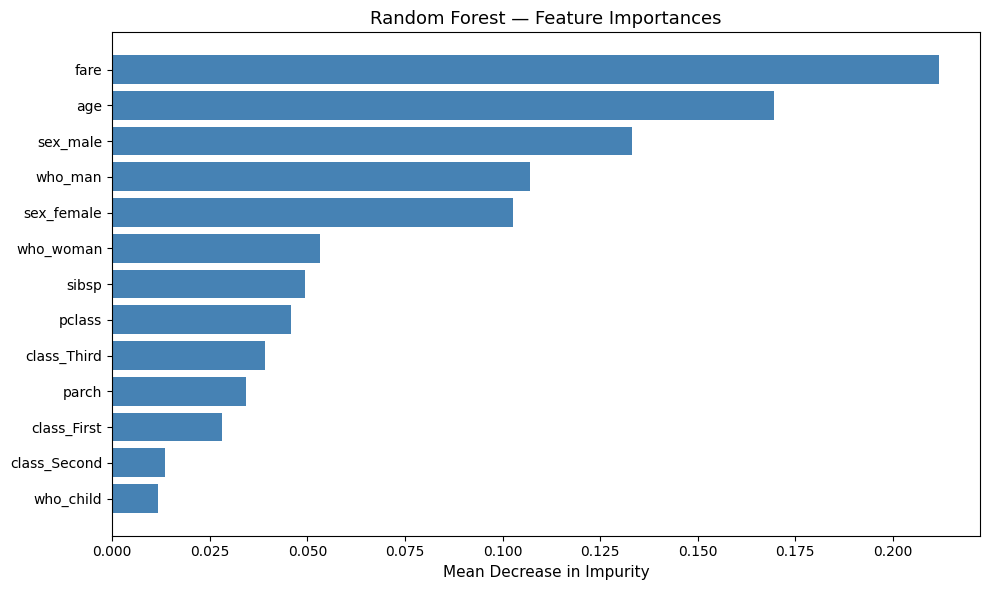

In [12]:
# Recover one-hot encoded feature names from the fitted pipeline
ohe_feature_names = (model_rf.best_estimator_['preprocessor']
                     .named_transformers_['cat']
                     .named_steps['onehot']
                     .get_feature_names_out(categorical_features))

all_feature_names = numerical_features + list(ohe_feature_names)
importances_rf = model_rf.best_estimator_['classifier'].feature_importances_

importance_df_rf = (pd.DataFrame({'Feature': all_feature_names, 'Importance': importances_rf})
                    .sort_values('Importance', ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df_rf['Feature'], importance_df_rf['Importance'], color='steelblue')
ax.invert_yaxis()
ax.set_title('Random Forest — Feature Importances', fontsize=13)
ax.set_xlabel('Mean Decrease in Impurity', fontsize=11)
plt.tight_layout()
plt.show()

**Observation:** `fare`, `age`, and `sex_male` rank among the top predictors.  
However, several features share information — for example `who_man`, `sex_male`, and `adult_male` are strongly correlated.  
This multicollinearity means individual importance scores should be interpreted cautiously; a permutation importance analysis or correlation study would provide a cleaner picture.


## 7. Model 2 — Logistic Regression

Scikit-learn's `Pipeline` makes it trivial to swap the estimator and re-run the search without touching any preprocessing code.


In [ ]:
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

param_grid_lr = {
    'classifier__solver': ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight': [None, 'balanced']
}

model_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

model_lr.fit(X_train, y_train)
print(f"\nBest parameters: {model_lr.best_params_}")
print(f"Best CV accuracy: {model_lr.best_score_:.2%}")

### 7.1 Evaluation on Held-Out Test Set

In [ ]:
y_pred_lr = model_lr.predict(X_test)
print("Logistic Regression — Classification Report")
print("=" * 45)
print(classification_report(y_test, y_pred_lr, target_names=['Did Not Survive', 'Survived']))

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=13, pad=12)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.show()

### 7.2 Coefficient Magnitudes

In [ ]:
coefficients = model_lr.best_estimator_.named_steps['classifier'].coef_[0]

coef_df = (pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefficients})
           .sort_values('Coefficient', ascending=False, key=abs))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d62728' if c < 0 else '#1f77b4' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'].abs(), color=colors)
ax.invert_yaxis()
ax.set_title('Logistic Regression — Feature Coefficient Magnitudes', fontsize=13)
ax.set_xlabel('|Coefficient|', fontsize=11)
plt.tight_layout()
plt.show()

**Observation:** Logistic regression surfaces a strikingly different importance ordering than the Random Forest.  
This divergence is a strong signal that multicollinear features (e.g. `sex_male` / `who_man` / `adult_male`) need to be consolidated, and that further feature engineering and a correlation analysis would improve interpretability for both models.


## 8. Model Comparison

In [ ]:
rf_acc  = model_rf.score(X_test, y_test)
lr_acc  = model_lr.score(X_test, y_test)
rf_cv   = model_rf.best_score_
lr_cv   = model_lr.best_score_

summary = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'CV Accuracy (best fold)': [f"{rf_cv:.2%}", f"{lr_cv:.2%}"],
    'Test Accuracy': [f"{rf_acc:.2%}", f"{lr_acc:.2%}"]
})

print(summary.to_string(index=False))

Both models achieve comparable test accuracy (~**80–82%**), with Logistic Regression slightly edging out Random Forest.  
The near-identical performance — despite very different feature importance profiles — highlights the importance of conducting a proper correlation and collinearity analysis before drawing conclusions about which features truly drive survival.

**Next steps to improve the pipeline:**
1. Add interaction features (e.g. `fare_per_person = fare / (1 + sibsp + parch)`)
2. Impute `age` using group medians (by `sex` and `pclass`) rather than the global median
3. Evaluate with AUC-ROC in addition to accuracy to better capture class imbalance
4. Try gradient boosting models (XGBoost / LightGBM) for a performance ceiling comparison


## 9. Conclusion

This project demonstrated a complete, interview-ready ML workflow:

| Step | Technique |
|:-----|:----------|
| Data exploration | `.value_counts()`, `.isnull().sum()` |
| Preprocessing | `ColumnTransformer` with median/mode imputation + scaling/OHE |
| Pipeline | `sklearn.pipeline.Pipeline` — prevents data leakage |
| Tuning | `GridSearchCV` + `StratifiedKFold` — respects class imbalance |
| Evaluation | Classification report, confusion matrix |
| Interpretability | Feature importances (RF) and coefficient magnitudes (LR) |
| Model comparison | Side-by-side CV and test accuracy |
